In [42]:
import pandas as pd
import numpy as np

## Read data from W&Bs
The CSV being read into pandas is from a W&Bs' report.

In [47]:
# dataframe = pd.read_csv('results-data/wandb_export_2025-08-24T12_09_08.262-04_00.csv')
dataframe = pd.read_csv('results-data/wandb_export_2025-08-24T18_35_17.680-04_00.csv')

In [48]:
N = 10

methods = [
    'eval-supervised-no-gnn', 'eval-supervised-v2-encoder',
    'eval-linear-probe-v2-encoder', 'eval-fine-tune-v2-encoder',
    'eval-linear-probe-v2-encoder-barlow-twins', 'eval-fine-tune-v2-encoder-barlow-twins',
    'eval-linear-probe-v2-encoder-bgrl', 'eval-fine-tune-v2-encoder-bgrl',
    'eval-linear-probe-v2-encoder-centering', 'eval-fine-tune-v2-encoder-centering'
    ]

precision_matrix = None
recall_matrix = None
f1_matrix = None

for method in methods:
    method_df = dataframe[dataframe.Name.str.contains(method)]

    if method in ('eval-linear-probe-v2-encoder', 'eval-fine-tune-v2-encoder'):
        method_df = method_df[~method_df.Name.str.contains('barlow-twins')]
        method_df = method_df[~method_df.Name.str.contains('bgrl')]
        method_df = method_df[~method_df.Name.str.contains('centering')]

    assert method_df.shape[0] == N

    # if method == 'eval-supervised-v2-encoder':

    prec_values = method_df.eval_precision.values[np.newaxis, :]
    recall_values = method_df.eval_recall.values[np.newaxis, :]
    f1_values = method_df.eval_f_score.values[np.newaxis, :]

    precision_matrix = prec_values if precision_matrix is None \
        else np.concatenate([precision_matrix, prec_values], axis=0)
    recall_matrix = recall_values if recall_matrix is None \
        else np.concatenate([recall_matrix, recall_values], axis=0)
    f1_matrix = f1_values if f1_matrix is None \
        else np.concatenate([f1_matrix, f1_values], axis=0)

In [ ]:
for i, method in enumerate(methods):
    prec_mean_val = precision_matrix[i].mean()
    prec_std_val = precision_matrix[i].std()

    recall_mean_val = recall_matrix[i].mean()
    recall_std_val = recall_matrix[i].std()

    f1_mean_val = f1_matrix[i].mean()
    f1_std_val = f1_matrix[i].std()

    print(f"{method} - ${prec_mean_val} \pm {prec_std_val}$, ${recall_mean_val} \pm {recall_std_val}$, ${f1_mean_val} \pm {f1_std_val}$")

eval-supervised-no-gnn - $0.0 \pm 0.0$, $0.0 \pm 0.0$, $0.0 \pm 0.0$
eval-supervised-v2-encoder - $0.31350932008387605 \pm 0.0749720422325035$, $0.17962292861251825 \pm 0.04400663435680447$, $0.22392247423937559 \pm 0.053816591165131294$
eval-linear-probe-v2-encoder - $0.04769665423370256 \pm 0.02916092578209385$, $0.02385806936480538 \pm 0.014565721670754862$, $0.03180426432110445 \pm 0.019430782423905894$
eval-fine-tune-v2-encoder - $0.4021298409694 \pm 0.03834168073074944$, $0.23206266585017352 \pm 0.022545221575970442$, $0.28789187032604047 \pm 0.027734982624218092$
eval-linear-probe-v2-encoder-barlow-twins - $0.013703167622334742 \pm 0.01848261239217076$, $0.00686619718309855 \pm 0.009231468598754037$, $0.0091451873295106 \pm 0.012315167912634912$
eval-fine-tune-v2-encoder-barlow-twins - $0.36826945202174843 \pm 0.06401277675867606$, $0.20891508471116552 \pm 0.04166815165875895$, $0.2613182321862665 \pm 0.048562526377211604$
eval-linear-probe-v2-encoder-bgrl - $0.00712436675388292

In [60]:
from scipy.stats import mannwhitneyu

# Compare No GNN (index=0) vs. GNN Supervised (index=1) using T-Test
# Alternate Hypothesis: Performance of supervised model with GNN is greater than performance without GNN.
no_gnn_vs_gnn_test = mannwhitneyu(f1_matrix[1, :], f1_matrix[0, :], alternative='greater')

# Compare GNN Supervised (index=1) vs. GNN Linear Probe (index=2)
# Alternate Hypothesis New: Performance of supervised GNN model is greater than linear probe model
gnn_vs_dino_linear_probe_test = mannwhitneyu(f1_matrix[1, :], f1_matrix[8, :], alternative='greater')

# Compare GNN Supervised (index=1) vs. GNN Fine-Tune (index=3)
# Alternate Hypothesis: Performance of fine-tuned GNN model is greater than performance of supervised GNN
gnn_vs_dino_fine_tune_test = mannwhitneyu(f1_matrix[9, :], f1_matrix[1, :], alternative='greater')

# Compare DINO without centering (index=3) vs. DINO with centering (index=9)
# dino_vs_dino_centering_fine_tune_test = mannwhitneyu(f1_matrix[3, :], f1_matrix[9, :], alternative='greater')

# gnn_vs_bgrl_linear_probe_ttest = ttest_ind(f1_matrix[1, :], f1_matrix[6, :], alternative='greater')
# gnn_vs_bgrl_fine_tune_ttest = ttest_ind(f1_matrix[7, :], f1_matrix[1, :], alternative='greater')

# gnn_vs_bt_linear_probe_ttest = ttest_ind(f1_matrix[1, :], f1_matrix[4, :], alternative='greater')
# gnn_vs_bt_fine_tune_ttest = ttest_ind(f1_matrix[5, :], f1_matrix[1, :], alternative='greater')

# dino_vs_bt_linear_probe_ttest = ttest_ind(f1_matrix[2, :], f1_matrix[4, :], alternative='greater')
# dino_vs_bt_fine_tune_ttest = ttest_ind(f1_matrix[3, :], f1_matrix[5, :], alternative='greater')

# dino_vs_bgrl_linear_probe_ttest = ttest_ind(f1_matrix[2, :], f1_matrix[6, :], alternative='greater')
# dino_vs_bgrl_fine_tune_ttest = ttest_ind(f1_matrix[3, :], f1_matrix[7, :], alternative='greater')

print(f"No GNN vs. GNN supervised model: {no_gnn_vs_gnn_test}")

print(f"GNN supervised vs. DINO linear probe model: {gnn_vs_dino_linear_probe_test}")
print(f"GNN supervised vs. DINO fine-tuned model: {gnn_vs_dino_fine_tune_test}")
# print(f"DINO vs. DINO (with centering): {dino_vs_dino_centering_fine_tune_test}")

# print(f"GNN supervised vs. BGRL linear probe model: {gnn_vs_bgrl_linear_probe_ttest}")
# print(f"GNN supervised vs. BGRL fine-tuned model: {gnn_vs_bgrl_fine_tune_ttest}")

# print(f"GNN supervised vs. GBT linear probe model: {gnn_vs_bt_linear_probe_ttest}")
# print(f"GNN supervised vs. GBT fine-tuned model: {gnn_vs_bt_fine_tune_ttest}")

# print(f"DINO vs. GBT (linear probe): {dino_vs_bt_linear_probe_ttest}")
# print(f"DINO vs. GBT (fine-tune): {dino_vs_bt_fine_tune_ttest}")

# print(f"DINO vs. BGRL (linear probe): {dino_vs_bgrl_linear_probe_ttest}")
# print(f"DINO vs. BGRL (fine-tune): {dino_vs_bgrl_fine_tune_ttest}")

# prec_stats = f_oneway(precision_matrix[0, :], precision_matrix[1, :],
#                       precision_matrix[2, :], precision_matrix[3, :])
# recall_stats = f_oneway(recall_matrix[0, :], recall_matrix[1, :],
#                         recall_matrix[2, :], recall_matrix[3, :])
# f1_stats = f_oneway(f1_matrix[0, :], f1_matrix[1, :],
#                     f1_matrix[2, :], f1_matrix[3, :])

# print(f"Precision stats: {prec_stats}")
# print(f"Recall stats: {recall_stats}")
# print(f"F1 score stats: {f1_stats}")

No GNN vs. GNN supervised model: MannwhitneyuResult(statistic=100.0, pvalue=3.193222375218491e-05)
GNN supervised vs. DINO linear probe model: MannwhitneyuResult(statistic=100.0, pvalue=9.133589555477501e-05)
GNN supervised vs. DINO fine-tuned model: MannwhitneyuResult(statistic=81.0, pvalue=0.01056696406458055)


In [50]:
import seaborn as sns

f1_df = pd.DataFrame(f1_matrix.T, columns=[m.replace('-','_') for m in methods])

In [51]:
f1_df.columns

Index(['eval_supervised_no_gnn', 'eval_supervised_v2_encoder',
       'eval_linear_probe_v2_encoder', 'eval_fine_tune_v2_encoder',
       'eval_linear_probe_v2_encoder_barlow_twins',
       'eval_fine_tune_v2_encoder_barlow_twins',
       'eval_linear_probe_v2_encoder_bgrl', 'eval_fine_tune_v2_encoder_bgrl',
       'eval_linear_probe_v2_encoder_centering',
       'eval_fine_tune_v2_encoder_centering'],
      dtype='object')

array([[<Axes: title={'center': 'eval_supervised_v2_encoder'}>]],
      dtype=object)

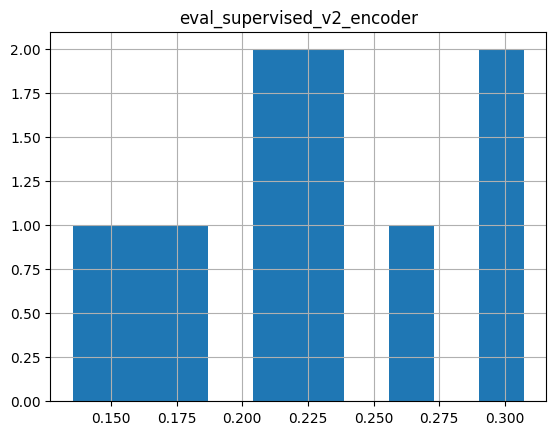

In [52]:
f1_df.hist('eval_supervised_v2_encoder')

array([[<Axes: title={'center': 'eval_supervised_no_gnn'}>]], dtype=object)

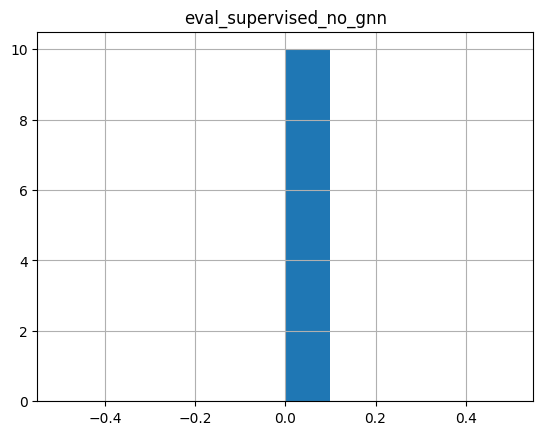

In [53]:
f1_df.hist('eval_supervised_no_gnn')

array([[<Axes: title={'center': 'eval_linear_probe_v2_encoder'}>]],
      dtype=object)

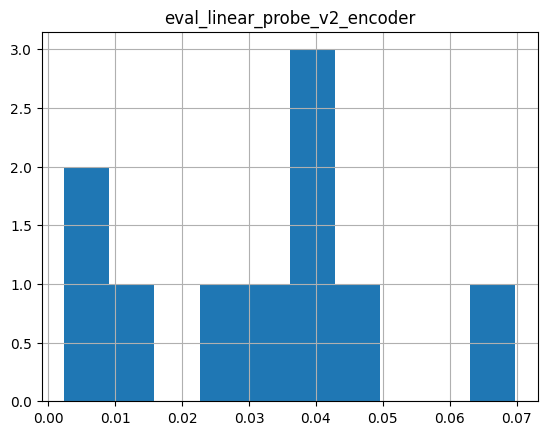

In [54]:
f1_df.hist('eval_linear_probe_v2_encoder')